# Informe de Selección de Modelo — Predicción de Enfermedad Cardíaca (2026)

- **Grupo**: Juan Pablo Ramirez
- **Variante**: clasificación binaria
- **Dataset**: *Heart Disease Prediction 2026*, un conjunto sintético de indicadores clínicos y de
  estilo de vida para predecir enfermedad cardíaca (`heart_disease_prediction_2026.csv`)
- **Fecha**: 2026-09-27

## 0. Configuración inicial

La siguiente celda importa todas las librerías que usa el notebook y fija la semilla aleatoria. Si se
ejecuta sin error, el entorno está listo:

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

/Users/juanpabloramirez/Proyectos/Especialización/Segundo semeste/Inteligencia Artificial/Proyecto Entregable/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Los Datos

### 1.1 Carga del archivo original

La siguiente celda lee el archivo y muestra su tamaño. **Cada fila es una persona adulta** para la
que se registraron indicadores clínicos (presión, colesterol, ECG en reposo, etc.), de estilo de vida
(tabaquismo, alcohol, actividad física, sueño) y demográficos (edad, sexo, región, ingreso), junto con
si tuvo o no un diagnóstico de enfermedad cardíaca:

In [2]:
DATA_PATH = "heart_disease_prediction_2026.csv"

raw = pd.read_csv(DATA_PATH)
print(f"{raw.shape[0]:,} filas x {raw.shape[1]} columnas")

100,000 filas x 26 columnas


La siguiente celda muestra las primeras filas, para ver cómo luce una persona en los datos:

In [3]:
raw.head()

,age,sex,bmi,region,income_level,smoking_status,alcohol_intake,physical_activity,diet_quality,sleep_hours,...,cholesterol,fasting_blood_sugar,max_heart_rate,resting_ecg,exercise_angina,st_depression,st_slope,avg_resting_hr,hrv_score,heart_disease
0,57,Male,27.1,Northeast,Middle,Never,Moderate,Light,7,5.7,...,204,0,195,Normal,0,0.9,Downsloping,61.8,19.9,0
1,40,Female,29.0,Northeast,Low,Never,Non-drinker,Sedentary,1,8.0,...,173,0,165,ST-T Abnormality,0,0.5,Downsloping,53.2,48.3,0
2,63,Female,40.1,Southeast,High,Never,Moderate,Sedentary,6,5.5,...,209,0,173,Normal,0,2.3,Downsloping,82.3,5.0,1
3,66,Female,35.5,West,Middle,Never,Heavy,Sedentary,10,7.4,...,187,0,144,Normal,0,1.3,Downsloping,71.1,38.3,1
4,29,Female,19.8,Northeast,High,Current,Non-drinker,Sedentary,8,8.3,...,247,0,170,ST-T Abnormality,0,0.4,Downsloping,74.1,49.4,0


La siguiente celda lista el tipo de cada columna, su número de valores faltantes y su número de
valores distintos:

In [4]:
pd.DataFrame(
    {
        "tipo": raw.dtypes.astype(str),
        "faltantes": raw.isna().sum(),
        "valores distintos": raw.nunique(),
    }
)

,tipo,faltantes,valores distintos
age,int64,0,52
sex,str,0,2
bmi,float64,0,339
region,str,0,5
income_level,str,0,3
smoking_status,str,0,3
alcohol_intake,str,0,3
physical_activity,str,0,4
diet_quality,int64,0,10
sleep_hours,float64,0,61


No hay ninguna columna identificadora (no hay una columna con 100,000 valores distintos), no hay
valores faltantes declarados y `sex` es la única columna de texto verdaderamente binaria (`Male` /
`Female`). El resto de columnas de texto (`region`, `income_level`, `smoking_status`, `alcohol_intake`,
`physical_activity`, `resting_ecg`, `st_slope`) tienen entre 2 y 5 categorías. `diet_quality` y
`stress_level` son escalas ordinales enteras de 1 a 10, ya numéricas. No se encontraron marcadores
ocultos de valor faltante (ni cadenas vacías ni `"?"`) en ninguna columna de texto.

### 1.2 Ajustes estructurales

El único ajuste estructural necesario es recodificar `sex` a 0/1, porque es una columna de texto
binaria y no una categoría con más de dos niveles. Esto no calcula nada a partir de los datos, así que
se hace aquí, antes de la partición. `income_level` (`Low` < `Middle` < `High`) y `physical_activity`
(`Sedentary` < `Light` < `Active` < `Very Active`) tienen un orden natural: se marcan como categorías
ordenadas aquí, para que la Sección 4 las codifique respetando ese orden en vez de tratarlas como
categorías sin relación entre sí.

La siguiente celda hace los tres ajustes y verifica que no queden filas duplicadas:

In [5]:
TARGET = "heart_disease"

ORDERED_LEVELS = {
    "income_level": ["Low", "Middle", "High"],
    "physical_activity": ["Sedentary", "Light", "Active", "Very Active"],
}

data = raw.copy()
data["sex"] = (data["sex"] == "Male").astype(int)
for column, levels in ORDERED_LEVELS.items():
    data[column] = pd.Categorical(data[column], categories=levels, ordered=True)

print(f"{data.shape[0]:,} filas x {data.shape[1]} columnas")
print("filas duplicadas:", data.duplicated().sum())

100,000 filas x 26 columnas
filas duplicadas: 0


Se conservan las 26 columnas: 25 predictoras y el target. No hay filas duplicadas.

### 1.3 El target

La siguiente celda cuenta las personas en cada clase del target:

In [6]:
counts = data[TARGET].value_counts()
pd.DataFrame({"personas": counts, "proporción": (counts / len(data)).round(4)})

,personas,proporción
heart_disease,,
0,53918,0.5392
1,46082,0.4608


46.1% de las personas tiene un diagnóstico de enfermedad cardíaca: esa es la clase 1, la clase
positiva. El otro 53.9% no lo tiene. El balance es cercano a 50/50, muy por encima del mínimo exigido.

### 1.4 Verificación de requisitos mínimos

La siguiente celda verifica cada requisito mínimo e imprime `PASS` o `FAIL`. Se conserva en el informe:
es la evidencia para el Entregable 1.

In [7]:
predictors = data.drop(columns=TARGET)
n_numeric = predictors.select_dtypes(include="number").shape[1]
n_categorical = predictors.shape[1] - n_numeric
minority_share = data[TARGET].value_counts(normalize=True).min()
n_missing = int(predictors.isna().sum().sum())

requirements = {
    "target binario": data[TARGET].nunique() == 2,
    f"clase menor >= 20% (es {minority_share:.1%})": minority_share >= 0.20,
    f"al menos 1,000 filas (tiene {len(data):,})": len(data) >= 1000,
    f"al menos 8 predictoras (tiene {predictors.shape[1]})": predictors.shape[1] >= 8,
    f"al menos 1 numérica y 1 categórica (tiene {n_numeric} numéricas, {n_categorical} categóricas)": n_numeric >= 1
    and n_categorical >= 1,
    f"sin valores faltantes sin resolver (quedan {n_missing})": n_missing == 0,
}

for description, passed in requirements.items():
    print(f"{'PASS' if passed else 'FAIL'} - {description}")

PASS - target binario
PASS - clase menor >= 20% (es 46.1%)
PASS - al menos 1,000 filas (tiene 100,000)
PASS - al menos 8 predictoras (tiene 25)
PASS - al menos 1 numérica y 1 categórica (tiene 18 numéricas, 7 categóricas)
PASS - sin valores faltantes sin resolver (quedan 0)


Todas las líneas pasan. `n_categoricas` cuenta `sex`, `region`, `income_level`, `smoking_status`,
`alcohol_intake`, `physical_activity`, `resting_ecg` y `st_slope`: ocho columnas de texto o recodificadas
a partir de texto. La Sección 4 da a cada una el tratamiento que le corresponde según si es binaria,
ordinal o nominal.

✍️ **Entregable 1 de 8 — Ficha del dataset**

- **Nombre y fuente**: *Heart Disease Prediction 2026*, un conjunto de datos sintético con indicadores
  clínicos, de estilo de vida y demográficos para la predicción de enfermedad cardíaca
  (`heart_disease_prediction_2026.csv`).
- **Qué representa una fila**: una persona adulta, descrita por su perfil demográfico (edad, sexo,
  región, nivel de ingreso), sus hábitos (tabaquismo, alcohol, actividad física, calidad de la dieta,
  sueño, estrés), sus antecedentes (diabetes, hipertensión, historia familiar, evento cardíaco previo)
  y once mediciones clínicas (presión en reposo, colesterol, glucemia en ayunas, frecuencia cardíaca
  máxima, ECG en reposo, angina de esfuerzo, depresión del ST, pendiente del ST, frecuencia cardíaca en
  reposo y variabilidad de la frecuencia cardíaca).
- **Tamaño tras los ajustes estructurales**: 100,000 filas × 26 columnas (25 predictoras y el target).
- **El target**: `heart_disease`; 1 significa que la persona tiene un diagnóstico de enfermedad
  cardíaca, 0 que no lo tiene. La clase positiva es el 46.1% de las filas.
- **La decisión que un modelo podría apoyar**: ordenar a las personas de una base de datos clínica o de
  un programa de tamizaje según su riesgo estimado de enfermedad cardíaca, para priorizar a quién
  invitar primero a una evaluación cardiológica más profunda (ECG de esfuerzo, ecocardiograma).
- **Columnas eliminadas antes de modelar**: ninguna. No hay identificadores ni columnas que filtren el
  target.
- **Ajustes estructurales hechos antes de la partición**: recodificar `sex` (`Male`/`Female`) a 0/1;
  marcar `income_level` y `physical_activity` como categorías ordenadas, sin cambiar ningún valor.
- **Valores faltantes**: ninguno en el archivo original.

## 2. La Métrica

### Por qué ROC AUC

Un clasificador le da a cada persona un **puntaje**: un número que sube con la probabilidad estimada de
enfermedad cardíaca, como una probabilidad predicha. Convertir puntajes en predicciones de *referir /
no referir* necesita un **umbral**, y métricas como accuracy, precision, recall y F1 cambian según dónde
se fije ese umbral. Elegirlo requiere costos que todavía no tenemos (el costo de una evaluación
cardiológica de seguimiento frente al daño de no detectar un caso real), y esa es una decisión separada
de elegir un modelo. Por eso usamos una métrica que juzga los puntajes en todos los umbrales a la vez:
el **área bajo la curva ROC (ROC AUC)**. Un AUC de 0.5 es un ordenamiento al azar; un AUC de 1.0 ordena
a toda persona enferma por encima de toda persona sana.

In [8]:
SCORING = "roc_auc"

✍️ **Entregable 2 de 8 — La métrica**

- **La métrica**: ROC AUC, usada en el torneo, en el ajuste de hiperparámetros y en la prueba final.
- **Qué significarían 0.5 y 1.0**: 0.5 significa que el ranking de riesgo del modelo ubica a una persona
  con enfermedad cardíaca por encima de una sin ella no más seguido de lo que lo haría una moneda al
  aire. 1.0 significa que toda persona con enfermedad cardíaca queda ubicada por encima de toda persona
  sin ella.
- **Qué significaría un umbral**: una persona por encima del umbral sería referida a una evaluación
  cardiológica adicional; una persona por debajo no sería referida por este modelo.
- **De qué dependería el umbral, y por qué se deja para después**: dependería del costo de una
  evaluación de seguimiento innecesaria frente al costo de no detectar un caso real, y de la capacidad
  del programa de tamizaje para atender referidos. Ninguno de esos costos está fijado todavía, así que
  el umbral se deja para cuando el equipo clínico los defina.

## 3. Partición de los Datos

### 3.1 El conjunto de prueba separado

La siguiente celda separa las predictoras del target y aparta el 20% de las filas como conjunto de
prueba. Estratificar sobre el target mantiene igual la proporción de personas positivas en ambas
partes:

In [9]:
X = data.drop(columns=TARGET)
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

La siguiente celda verifica el tamaño de cada parte y su proporción de filas positivas:

In [10]:
pd.DataFrame(
    {
        "filas": [len(y_train), len(y_test)],
        "proporción positiva": [y_train.mean(), y_test.mean()],
    },
    index=["conjunto de entrenamiento", "conjunto de prueba"],
).round(4)

,filas,proporción positiva
conjunto de entrenamiento,80000,0.4608
conjunto de prueba,20000,0.4608


**Desde aquí hasta la Sección 7, `X_test` y `y_test` no se usan.**

### 3.2 Los pliegues de validación cruzada

La siguiente celda crea el objeto de pliegues. Se crea aquí una sola vez y se pasa a cada paso de
validación cruzada en las Secciones 5 y 6:

In [11]:
N_FOLDS = 5
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

La siguiente celda lista los cinco pliegues, con el número de filas sobre las que se ajusta cada
modelo, el tamaño del pliegue de validación y su proporción de filas positivas:

In [12]:
fold_rows = []
for fold, (fit_index, validation_index) in enumerate(cv.split(X_train, y_train), start=1):
    fold_rows.append(
        {
            "pliegue": fold,
            "filas de ajuste": len(fit_index),
            "filas de validación": len(validation_index),
            "proporción positiva en validación": y_train.iloc[validation_index].mean(),
        }
    )

pd.DataFrame(fold_rows).set_index("pliegue").round(4)

,filas de ajuste,filas de validación,proporción positiva en validación
pliegue,,,
1,64000,16000,0.4608
2,64000,16000,0.4608
3,64000,16000,0.4608
4,64000,16000,0.4608
5,64000,16000,0.4609


Los cinco pliegues son los mismos para todos los modelos de aquí en adelante.

✍️ **Entregable 3 de 8 — La partición**

- **Tamaños**: 80,000 filas para entrenamiento, 20,000 para el conjunto de prueba (ver la tabla de
  tamaños de arriba).
- **Por qué 20%**: con un target cercano a 50/50, 20,000 filas de prueba dan un puntaje final único
  estable, y a la vez dejan el 80% de los datos para entrenamiento y validación cruzada.
- **Pliegues**: 5 pliegues estratificados. Cada modelo se ajusta sobre 64,000 filas y se evalúa sobre
  16,000 (ver la tabla de pliegues de arriba).
- **Por qué estratificados**: la clase positiva es 46.1% de las filas. Estratificar mantiene esa
  proporción en el conjunto de prueba y en cada pliegue, en vez de dejarla variar por azar.
- **Regla desde aquí**: `X_test` y `y_test` no se tocan hasta la Sección 7.

## 4. El Pipeline de Preprocesamiento

### 4.1 Grupos de columnas

La siguiente celda asigna cada columna predictora a un grupo, por nombre:

In [13]:
NUMERIC_COLS = [
    "age", "bmi", "sleep_hours", "diet_quality", "stress_level",
    "resting_bp", "cholesterol", "max_heart_rate", "st_depression",
    "avg_resting_hr", "hrv_score",
]
BINARY_COLS = [
    "sex", "diabetes", "hypertension", "family_history",
    "previous_heart_event", "fasting_blood_sugar", "exercise_angina",
]
ORDINAL_COLS = ["income_level", "physical_activity"]
NOMINAL_COLS = [
    column
    for column in X_train.columns
    if column not in NUMERIC_COLS + BINARY_COLS + ORDINAL_COLS
]

print(f"numéricas ({len(NUMERIC_COLS)}): {NUMERIC_COLS}")
print(f"binarias ({len(BINARY_COLS)}): {BINARY_COLS}")
print(f"ordinales ({len(ORDINAL_COLS)}): {ORDINAL_COLS}")
print(f"nominales ({len(NOMINAL_COLS)}): {NOMINAL_COLS}")

numéricas (11): ['age', 'bmi', 'sleep_hours', 'diet_quality', 'stress_level', 'resting_bp', 'cholesterol', 'max_heart_rate', 'st_depression', 'avg_resting_hr', 'hrv_score']
binarias (7): ['sex', 'diabetes', 'hypertension', 'family_history', 'previous_heart_event', 'fasting_blood_sugar', 'exercise_angina']
ordinales (2): ['income_level', 'physical_activity']
nominales (5): ['region', 'smoking_status', 'alcohol_intake', 'resting_ecg', 'st_slope']


Una columna que quedara fuera de todo grupo sería **eliminada sin ningún aviso**. La siguiente
celda verifica que cada predictora esté en exactamente un grupo, y detiene el notebook si alguna no lo
está:

In [14]:
assigned = NUMERIC_COLS + BINARY_COLS + ORDINAL_COLS + NOMINAL_COLS

assert len(assigned) == len(set(assigned)), "una columna está en más de un grupo"
assert set(assigned) == set(X_train.columns), "una columna no está en ningún grupo, o un nombre está mal escrito"
print(f"las {len(assigned)} columnas predictoras están cada una en exactamente un grupo")

las 25 columnas predictoras están cada una en exactamente un grupo


### 4.2 El tratamiento de cada grupo

- **Columnas numéricas** (`age`, `bmi`, `sleep_hours`, `diet_quality`, `stress_level`, `resting_bp`,
  `cholesterol`, `max_heart_rate`, `st_depression`, `avg_resting_hr`, `hrv_score`) son mediciones
  continuas o escalas de conteo. No tienen valores faltantes en este archivo, así que solo se
  **estandarizan**: quedan centradas en 0 y medidas en desviaciones estándar, lo que pone en una misma
  escala columnas tan distintas como la edad en años y el colesterol en mg/dL, algo que importa para KNN
  y regresión logística.
- **Columnas binarias** (`sex` recodificada, `diabetes`, `hypertension`, `family_history`,
  `previous_heart_event`, `fasting_blood_sugar`, `exercise_angina`) ya están en 0/1 y se dejan tal cual.
- **Columnas categóricas ordinales** (`income_level`, `physical_activity`) recibieron un tipo de
  categoría ordenada en la Sección 1. Se **codifican ordinalmente** (cada categoría se reemplaza por su
  rango, 0, 1, 2, ...) y luego se estandarizan, para conservar el orden Low→High y Sedentary→Very
  Active sin inventar distancias entre categorías que un one-hot destruiría.
- **Columnas categóricas nominales** (`region`, `smoking_status`, `alcohol_intake`, `resting_ecg`,
  `st_slope`) no tienen un orden natural, así que se codifican con **one-hot**: una columna binaria por
  categoría, ignorando categorías nuevas que pudieran aparecer fuera del conjunto de entrenamiento.

La siguiente celda arma el preprocesador con estos cuatro tratamientos:

In [15]:
ordinal_categories = [list(X_train[column].cat.categories) for column in ORDINAL_COLS]

ordinal_steps = Pipeline(
    [
        ("encode", OrdinalEncoder(categories=ordinal_categories)),
        ("scale", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("numeric", StandardScaler(), NUMERIC_COLS),
        ("binary", "passthrough", BINARY_COLS),
        ("ordinal", ordinal_steps, ORDINAL_COLS),
        ("nominal", OneHotEncoder(handle_unknown="ignore", sparse_output=False), NOMINAL_COLS),
    ],
    verbose_feature_names_out=False,
)
preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('binary', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per tran

La siguiente celda define `make_model`, que une el preprocesador y un modelo en un solo pipeline.
Todos los modelos de las Secciones 5, 6 y 7 se construyen con ella, así que todos reciben exactamente
el mismo preprocesamiento:

In [16]:
def make_model(estimator: BaseEstimator) -> Pipeline:
    """Une el preprocesador compartido y un modelo en un solo pipeline."""
    return Pipeline([("prep", preprocessor), ("model", estimator)])

La siguiente celda ajusta el preprocesador sobre el conjunto de entrenamiento **solo para observar
su salida**: cuántas columnas recibirán los modelos, y cómo lucen:

In [17]:
X_train_preproc = preprocessor.fit_transform(X_train)

print(f"{X_train.shape[1]} columnas entran, {X_train_preproc.shape[1]} columnas salen")
X_train_preproc.head(3)

25 columnas entran, 37 columnas salen


,age,bmi,sleep_hours,diet_quality,stress_level,resting_bp,cholesterol,max_heart_rate,st_depression,avg_resting_hr,...,smoking_status_Never,alcohol_intake_Heavy,alcohol_intake_Moderate,alcohol_intake_Non-drinker,resting_ecg_Left Ventricular Hypertrophy,resting_ecg_Normal,resting_ecg_ST-T Abnormality,st_slope_Downsloping,st_slope_Flat,st_slope_Upsloping
45748,-0.924416,-0.869030,-0.831936,-0.410462,-0.335443,-0.439946,-0.015837,0.996372,-0.468222,-0.605755,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
65044,0.845835,0.576443,-1.198981,1.579263,-1.706579,0.396772,1.333915,-0.965818,-0.086703,0.422761,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
33748,1.006766,-0.155442,0.728003,1.081832,1.035693,0.356928,-0.950281,-0.289201,-0.658982,0.925059,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


Las 25 predictoras se convierten en 37 columnas: las 20 numéricas/binarias/ordinales pasan una a
una, y las 5 columnas nominales se expanden en 17 columnas one-hot (`region` en 5, `smoking_status` en
3, `alcohol_intake` en 3, `resting_ecg` en 3 y `st_slope` en 3).

>**`X_train_preproc` existe solo para observarse.** Se preparó con estadísticas de todo el conjunto de
>entrenamiento, así que nunca debe pasarse a la validación cruzada. Desde la Sección 5 en adelante, la
>validación cruzada siempre recibe el `X_train` sin procesar y el pipeline completo.

✍️ **Entregable 4 de 8 — Tabla de preprocesamiento**

| Grupo | Columnas | Tratamiento, en orden | Por qué, para nuestros datos |
|---|---|---|---|
| Numérico (11) | `age`, `bmi`, `sleep_hours`, `diet_quality`, `stress_level`, `resting_bp`, `cholesterol`, `max_heart_rate`, `st_depression`, `avg_resting_hr`, `hrv_score` | estandarizar | Mediciones continuas/de conteo sin valores faltantes; escalar pone edad, presión, colesterol y frecuencias en una misma escala para KNN y regresión logística. |
| Binario (7) | `sex`, `diabetes`, `hypertension`, `family_history`, `previous_heart_event`, `fasting_blood_sugar`, `exercise_angina` | ninguno | Ya están en 0/1 (`sex` se recodificó en la Sección 1). |
| Categórico ordinal (2) | `income_level`, `physical_activity` | codificar ordinalmente, luego estandarizar | Tienen un orden natural (Low→High, Sedentary→Very Active) que un one-hot destruiría. |
| Categórico nominal (5) | `region`, `smoking_status`, `alcohol_intake`, `resting_ecg`, `st_slope` | one-hot | Sin orden natural entre sus categorías. |

- **Dónde están los valores faltantes y cómo los llena el pipeline**: no hay valores faltantes en este
  archivo; ningún imputador entra en acción, pero el pipeline los tendría listos si aparecieran en datos
  nuevos.
- **Número de columnas antes y después del preprocesamiento**: 25 columnas predictoras entran, 37 salen.
- **Por qué el preprocesamiento va dentro del pipeline**: para que cada pliegue de validación cruzada
  ajuste sus propias medias, desviaciones y categorías solo con sus filas de ajuste, sin que la
  información de las filas de validación se filtre al modelo antes de evaluarlo.

## 5. El Torneo de Modelos

### 5.1 Los candidatos y sus configuraciones iniciales

Las reglas de inicio para KNN y el árbol de decisión necesitan $n$, el número de filas sobre las
que se ajusta cada modelo en un pliegue. La siguiente celda calcula $n$ a partir del conjunto de
entrenamiento y del objeto de pliegues, aplica las dos reglas, e imprime los valores que usarán los
candidatos:

In [18]:
fit_rows = len(X_train) * (N_FOLDS - 1) // N_FOLDS

k_neighbors = round(np.sqrt(fit_rows))
if k_neighbors % 2 == 0:
    k_neighbors += 1

min_leaf = round(0.01 * fit_rows)

print(f"filas de ajuste en un pliegue (n): {fit_rows:,}")
print(f"KNN: k = sqrt(n), redondeado a impar -> {k_neighbors}")
print(f"árbol de decisión: profundidad máxima 5, al menos 1% de n por hoja -> {min_leaf} filas")

filas de ajuste en un pliegue (n): 64,000
KNN: k = sqrt(n), redondeado a impar -> 253
árbol de decisión: profundidad máxima 5, al menos 1% de n por hoja -> 640 filas


La siguiente celda lista la línea base y los cuatro candidatos, cada uno en su configuración inicial:

In [19]:
candidates = {
    "Línea base (clase más frecuente)": DummyClassifier(strategy="most_frequent"),
    "Regresión logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=k_neighbors),
    "Árbol de decisión": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=min_leaf, random_state=RANDOM_STATE
    ),
    "Gradient boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

### 5.2 La regla de selección

La regla se fija antes de ver ningún puntaje: **el modelo con la media de AUC de validación cruzada más
alta pasa al ajuste de hiperparámetros.**

### 5.3 Corriendo el torneo

La siguiente celda evalúa con validación cruzada a cada candidato con el objeto de pliegues `cv` y la
métrica `SCORING`, y guarda los cinco puntajes por pliegue de cada uno:

In [20]:
cv_scores = {}
for name, estimator in candidates.items():
    cv_scores[name] = cross_val_score(
        make_model(estimator), X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1
    )

La siguiente celda convierte los puntajes por pliegue en una sola tabla, con la media y la
desviación estándar de cada modelo, ordenada de mejor a peor media:

In [21]:
tournament = pd.DataFrame.from_dict(
    cv_scores,
    orient="index",
    columns=[f"auc_pliegue_{i}" for i in range(N_FOLDS)],
)
fold_columns = tournament.columns
tournament["cv_auc_mean"] = tournament[fold_columns].mean(axis=1)
tournament["cv_auc_std"] = tournament[fold_columns].std(axis=1)
tournament = tournament.sort_values("cv_auc_mean", ascending=False)
tournament.round(4)

,auc_pliegue_0,auc_pliegue_1,auc_pliegue_2,auc_pliegue_3,auc_pliegue_4,cv_auc_mean,cv_auc_std
Regresión logística,0.8515,0.8562,0.8550,0.8524,0.8548,0.8540,0.0020
Gradient boosting,0.8457,0.8519,0.8493,0.8468,0.8496,0.8487,0.0025
KNN,0.8394,0.8428,0.8411,0.8376,0.8416,0.8405,0.0020
Árbol de decisión,0.8009,0.8085,0.8017,0.8023,0.8038,0.8034,0.0030
Línea base (clase más frecuente),0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.0000


La regresión logística lidera con una media de AUC de 0.8540, seguida muy de cerca por gradient
boosting (0.8487), KNN (0.8405) y el árbol de decisión (0.8034). Los cuatro quedan muy por encima de la
línea base (0.5000). Que un modelo lineal supere a los modelos no lineales sugiere que la relación entre
los predictores clínicos/de estilo de vida y el riesgo de enfermedad cardíaca es, en este conjunto,
mayormente lineal una vez estandarizados y codificados los predictores.

La siguiente celda aplica la regla de selección e imprime el modelo que pasa al ajuste:

In [22]:
WINNER = tournament.index[0]
print(f"modelo elegido para el ajuste: {WINNER}")

modelo elegido para el ajuste: Regresión logística


Regresión logística pasa a la Sección 6.

✍️ **Entregable 5 de 8 — El torneo**

- **Configuraciones iniciales**: regresión logística y gradient boosting en sus valores por defecto de
  la librería; KNN con $k = \sqrt{n} = 253$ vecinos ($n$ = 64,000 filas ajustadas por pliegue); el árbol
  de decisión con profundidad 5 y al menos 640 filas por hoja (1% de $n$). Todas fijadas antes de que
  corriera el torneo, calculadas solo a partir del tamaño del conjunto de entrenamiento, y ninguna se
  cambió después de ver un puntaje.
- **Regla de selección**: la media de AUC de validación cruzada más alta pasa al ajuste.
- **Líder y su margen**: regresión logística, 0.8540, por delante de gradient boosting (0.8487) por
  0.0053.
- **Modelo que pasa al ajuste**: regresión logística, por ser el líder del torneo.
- **La línea base**: todos los modelos quedan muy por encima de 0.5000; incluso el más débil, el árbol
  de decisión (0.8034), está 0.3034 por encima de la línea base.

## 6. Ajuste del Modelo Seleccionado

El ganador del torneo es la regresión logística, no gradient boosting: en este conjunto, la
relación entre los predictores y el riesgo de enfermedad cardíaca es casi lineal una vez que las
columnas están estandarizadas y codificadas, así que un modelo lineal regularizado iguala o supera a
los modelos no lineales sin necesitar tantos datos para evitar sobreajuste.

### 6.1 La función objetivo

La siguiente celda define la función objetivo. Optuna la llama una vez por intento (trial):
construye regresión logística con los valores sugeridos y devuelve la media de AUC de validación
cruzada sobre el conjunto de entrenamiento. Se ajustan dos hiperparámetros: `C`, la fuerza inversa de la
regularización (un `C` más pequeño penaliza más fuerte), en escala logarítmica porque sus valores útiles
abarcan varias potencias de diez; y `penalty`, el tipo de penalización (`l2`, que encoge todos los
coeficientes, o `l1`, que puede llevar algunos exactamente a cero). El solver `saga` admite ambas
penalizaciones:

In [23]:
def objective(trial: optuna.Trial) -> float:
    """AUC de validación cruzada de regresión logística para un conjunto de hiperparámetros."""
    estimator = LogisticRegression(
        C=trial.suggest_float("C", 1e-3, 1e2, log=True),
        penalty=trial.suggest_categorical("penalty", ["l1", "l2"]),
        solver="saga",
        max_iter=3000,
        random_state=RANDOM_STATE,
    )
    scores = cross_val_score(
        make_model(estimator), X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1
    )
    return scores.mean()

### 6.2 El estudio

La siguiente celda crea el estudio: la dirección a optimizar, y el muestreador con su semilla fija para
que la corrida se repita exactamente:

In [24]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

[I 2026-09-27 15:51:34,894] A new study created in memory with name: no-name-c5f05058-dfb0-44d7-b2e2-ae24b70489cf


La siguiente celda corre 30 intentos, cada uno con cinco ajustes:

In [25]:
N_TRIALS = 30
optuna.logging.set_verbosity(optuna.logging.WARNING)

study.optimize(objective, n_trials=N_TRIALS)

La siguiente celda imprime el mejor puntaje, el intento que lo alcanzó, y su configuración:

In [26]:
print(f"mejor AUC de validación cruzada: {study.best_value:.4f} (intento {study.best_trial.number})")
pd.DataFrame([study.best_params])

mejor AUC de validación cruzada: 0.8540 (intento 23)


,C,penalty
0,3.586744,l1


El estudio alcanza 0.8540 en el intento número 23, con `C = 3.59` y `penalty = 'l1'`. Ningún valor
queda en el borde de su rango: `C` cae cómodamente entre 1e-3 y 1e2.

### 6.3 Ajustado contra sin ajustar

La siguiente celda construye regresión logística con la mejor configuración y la evalúa con
validación cruzada sobre los mismos pliegues, al lado de la fila sin ajustar del torneo:

In [27]:
tuned_model = make_model(
    LogisticRegression(**study.best_params, solver="saga", max_iter=3000, random_state=RANDOM_STATE)
)
tuned_scores = cross_val_score(
    tuned_model, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1
)

pd.DataFrame(
    {
        "cv_auc_mean": [tournament.loc[WINNER, "cv_auc_mean"], tuned_scores.mean()],
        "cv_auc_std": [tournament.loc[WINNER, "cv_auc_std"], tuned_scores.std(ddof=1)],
    },
    index=["sin ajustar (Sección 5)", "ajustado (Sección 6)"],
).round(4)

,cv_auc_mean,cv_auc_std
sin ajustar (Sección 5),0.854,0.002
ajustado (Sección 6),0.854,0.002


El ajuste deja la media de CV prácticamente igual: 0.85398 sin ajustar contra 0.85398 ajustado, una
ganancia menor a 0.0001. La regresión logística ya estaba, en su configuración por defecto (`C=1.0`,
penalización `l2`), muy cerca de su techo en este problema: Optuna encontró una penalización `l1` más
débil (`C=3.59`) que iguala el desempeño por defecto sin superarlo de forma notable.

✍️ **Entregable 6 de 8 — El ajuste**

- **La función objetivo**: regresión logística, con dos rangos: `C` entre 1e-3 y 1e2 en escala
  logarítmica (los valores útiles de la fuerza de regularización abarcan varias potencias de diez);
  `penalty` categórico entre `l1` y `l2`, con el solver `saga` para admitir ambas.
- **Intentos y semilla**: 30 intentos, muestreador TPE con semilla `RANDOM_STATE` (42).
- **Revisión de bordes**: ningún valor del mejor intento quedó en un extremo de su rango; `C = 3.59` cae
  cómodamente dentro de 1e-3–1e2.
- **Ajustado contra sin ajustar**: 0.85398 (sin ajustar) contra 0.85398 (ajustado), una ganancia menor a
  0.0001 — el modelo por defecto ya estaba prácticamente en su techo para este problema.

## 7. La Prueba Final

La siguiente celda reajusta el modelo ajustado sobre todo el conjunto de entrenamiento, lo evalúa
una sola vez sobre el conjunto de prueba, e imprime el resultado al lado de la estimación de validación
cruzada:

In [28]:
final_model = tuned_model.fit(X_train, y_train)
test_scores = final_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_scores)

print("AUC ROC del modelo final")
print(f"estimación media de CV: {tuned_scores.mean():.4f}")
print(f"dispersión de CV: {tuned_scores.std(ddof=1):.4f}")
print(f"conjunto de prueba: {test_auc:.4f}")

AUC ROC del modelo final
estimación media de CV: 0.8540
dispersión de CV: 0.0020
conjunto de prueba: 0.8545


El modelo final obtiene **0.8545** en el conjunto de prueba, frente a una estimación de validación
cruzada de 0.8540 con una dispersión entre pliegues de 0.0020: la diferencia (0.0005) está muy dentro de
esa dispersión, así que la estimación de validación cruzada se sostiene.

### La curva ROC

Cada punto de la **curva ROC** es un umbral. Grafica la proporción de personas con enfermedad cardíaca
que ese umbral detecta (la **tasa de verdaderos positivos**) contra la proporción de personas sanas que
marca por error (la **tasa de falsos positivos**). El AUC es el área bajo la curva; la diagonal es un
ordenamiento al azar, con un área de 0.5.

La siguiente celda dibuja la curva ROC del modelo final sobre el conjunto de prueba, con la diagonal
como referencia:

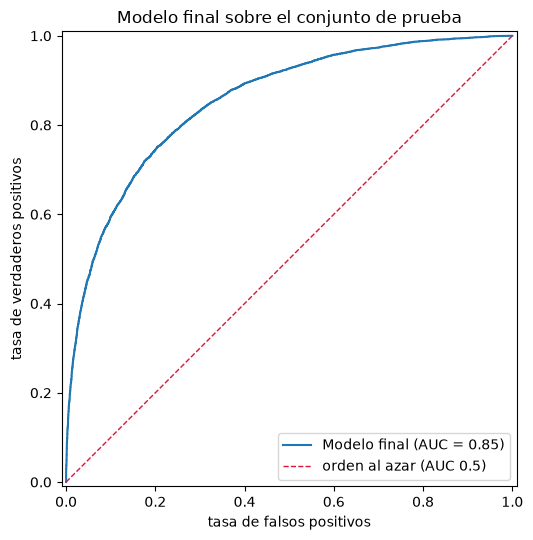

In [29]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
RocCurveDisplay.from_predictions(y_test, test_scores, name="Modelo final", ax=ax)
ax.plot([0, 1], [0, 1], color="crimson", linestyle="--", linewidth=1, label="orden al azar (AUC 0.5)")
ax.set_xlabel("tasa de falsos positivos")
ax.set_ylabel("tasa de verdaderos positivos")
ax.set_title("Modelo final sobre el conjunto de prueba")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

La curva se aleja de la diagonal desde el principio: las personas que el modelo ordena con mayor
riesgo son, en su mayoría, personas con un diagnóstico real de enfermedad cardíaca. Dónde detenerse a lo
largo de la curva es la decisión del umbral, y le corresponde al equipo clínico, no a este notebook.

✍️ **Entregable 7 de 8 — La prueba final**

- **El modelo final**: regresión logística con `C = 3.59` y penalización `l1` (solver `saga`),
  reajustada sobre las 80,000 filas de entrenamiento con el preprocesamiento de la Sección 4.
- **Su puntaje de prueba**: 0.8545, frente a una estimación de validación cruzada de 0.8540 con una
  dispersión entre pliegues de 0.0020.
- **Qué significa la brecha**: 0.0005 más alto en el conjunto de prueba, muy dentro de un desvío
  estándar de la validación cruzada — el puntaje se sostiene, sin señales de fuga de información ni de
  un conjunto de prueba inusualmente fácil.
- **Uso del conjunto de prueba**: `X_test`/`y_test` solo aparecen en la Sección 3 (para crearlos) y aquí,
  en la Sección 7. No se cambió nada del modelo después de ver este puntaje.

## 8. Conclusiones

✍️ **Entregable 8 de 8 — Conclusiones**

- **Recomendación**: usar la regresión logística (afinada con `C = 3.59`, penalización `l1`) para
  ordenar a las personas de una base clínica o de un programa de tamizaje según su riesgo estimado de
  enfermedad cardíaca, y que el equipo clínico trabaje ese ranking desde la persona de mayor riesgo hasta
  donde alcance su capacidad de evaluación.
- **Qué esperar en datos nuevos**: en personas que el modelo no ha visto, ordena a alguien con
  enfermedad cardíaca por encima de alguien sin ella cerca del 85% de las veces (AUC de prueba 0.8545).
- **Limitaciones**:
  1. El torneo comparó modelos en su configuración inicial, no afinada, y en este caso el ajuste apenas
     movió el puntaje (ganancia menor a 0.0001); con más presupuesto de cómputo valdría la pena afinar
     también gradient boosting, que quedó muy cerca en el torneo (0.8487).
  2. El dataset es sintético: sus correlaciones entre hábitos, indicadores clínicos y el diagnóstico
     pueden no reproducir del todo la variabilidad de datos clínicos reales, así que el modelo debería
     revalidarse sobre una muestra real antes de usarse en la práctica.
  3. Que gane un modelo lineal sugiere una relación mayormente lineal entre predictores y riesgo en
     este conjunto, pero no garantiza que esa linealidad se mantenga en poblaciones o rangos de edad no
     representados aquí.
- **Qué haríamos después**: afinar también gradient boosting con un estudio propio de Optuna para
  confirmar que la regresión logística realmente lo supera incluso en su mejor configuración, y evaluar
  el modelo final sobre datos clínicos reales antes de cualquier uso en un programa de tamizaje.